In [229]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [230]:
df = pd.read_csv('loan_approval_data.csv')


In [231]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        951 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          49
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [232]:
# handle missing values 
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=["number"]).columns



In [233]:
categorical_cols.size + numerical_cols.size

20

In [234]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [235]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])



In [236]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Car,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [237]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[numerical_cols] = cat_imp.fit_transform(df[numerical_cols])

In [238]:
df.head()
df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          49
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

EDA

Text(0.5, 1.0, ' is load aaprovesd or not')

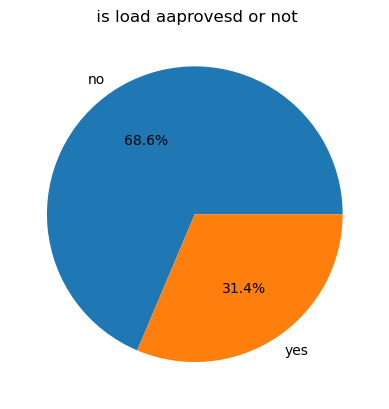

In [239]:
# how balanced oue data are

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["no", "yes"], autopct='%1.1f%%')
plt.title(" is load aaprovesd or not")

[Text(0, 0, '571'), Text(0, 0, '379')]

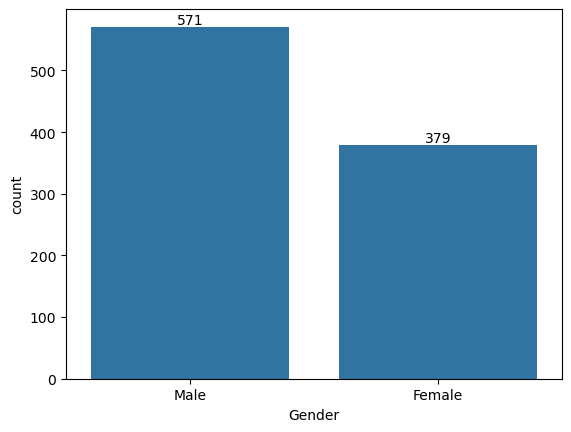

In [240]:
# alalyze categorical data
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

# alalyze categorical data


[Text(0, 0, '672'), Text(0, 0, '278')]

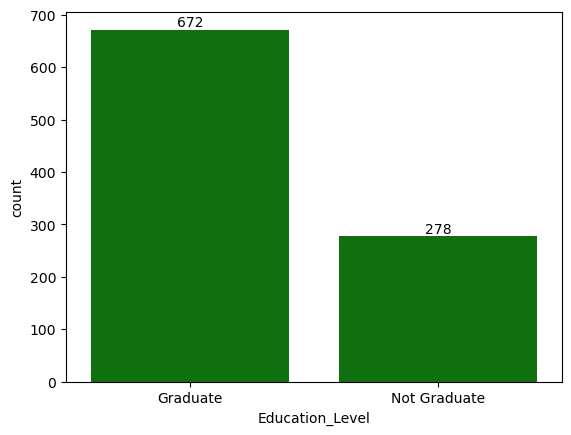

In [241]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt, color = "green")
ax.bar_label(ax.containers[0])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

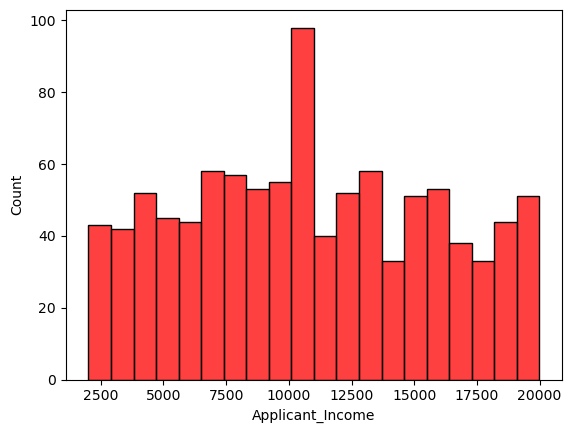

In [242]:
# income
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20,
    color = "red",
)


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

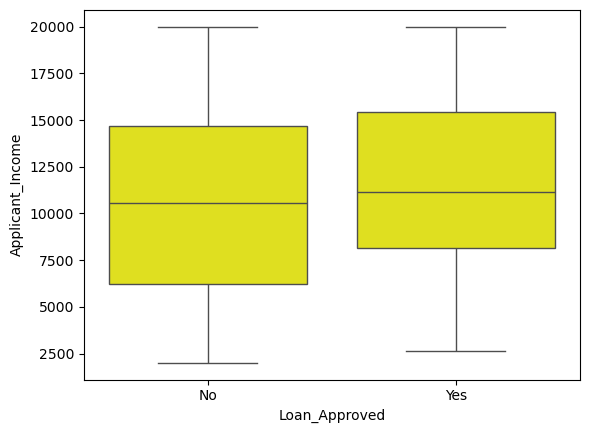

In [243]:
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income",
    color = "yellow"
    
)

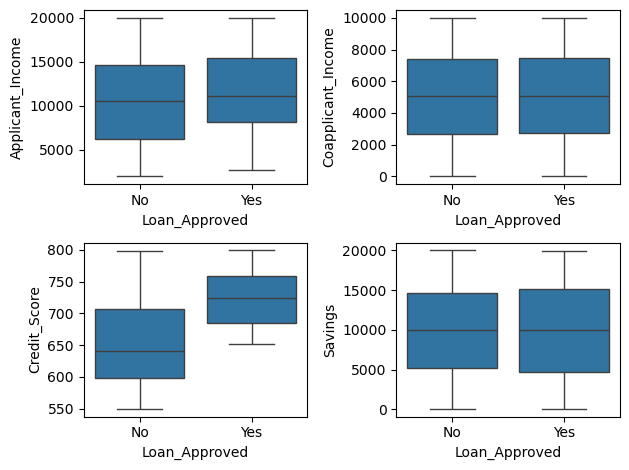

In [244]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df, x = "Loan_Approved", y = "Coapplicant_Income")
sns.boxplot(ax = axes[1,0], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1,1], data = df, x = "Loan_Approved", y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

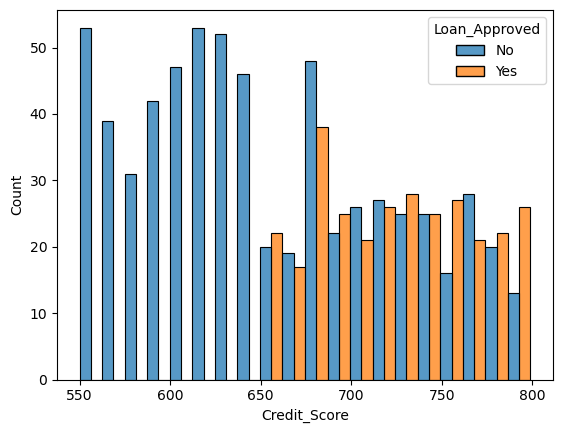

In [245]:
# credit schote 

sns.histplot(
    data= df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge",
    color = ["red", "green"]
    
)

In [246]:
# remove applicant id
df = df.drop("Applicant_ID", axis = 1)

In [247]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Car,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


feature Encoading

In [248]:
cols = ["Employment_Status", "Gender", "Marital_Status", "Property_Area", "Loan_Purpose","Employer_Category","Education_Level",]

ohe = OneHotEncoder(drop = "first", sparse_output=False , handle_unknown = "ignore")

encoded = ohe.fit_transform(df[cols])   

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns = cols), encoded_df], axis=1)

In [249]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan,Education_Level_Not Graduate,Education_Level_nan
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [250]:
df.head()   
df.describe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Loan_Approved                    950 non-null    object 
 12  Employment_Status_Sal

Heatmap

<Axes: >

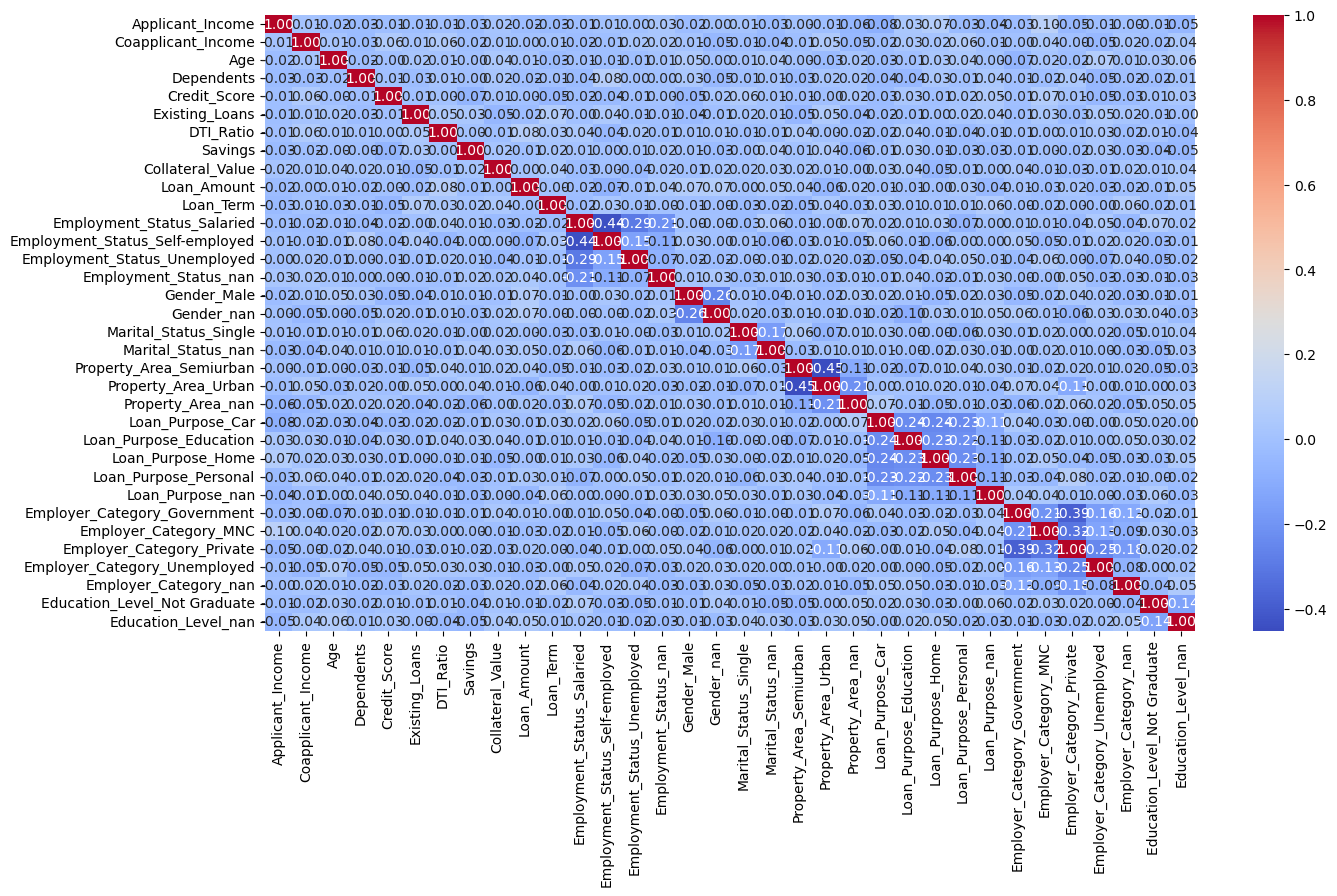

In [251]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [252]:
# train test split 

X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [253]:
X.head()
df.describe

<bound method NDFrame.describe of      Applicant_Income  Coapplicant_Income   Age  Dependents  Credit_Score  \
0        17795.000000              1387.0  51.0         0.0         637.0   
1         2860.000000              2679.0  46.0         3.0         621.0   
2         7390.000000              2106.0  25.0         2.0         674.0   
3        13964.000000              8173.0  40.0         2.0         579.0   
4        13284.000000              4223.0  31.0         2.0         721.0   
..                ...                 ...   ...         ...           ...   
995      10852.571579              9092.0  58.0         0.0         557.0   
996       3279.000000              6356.0  58.0         1.0         646.0   
997      15192.000000              8433.0  48.0         1.0         666.0   
998       9083.000000              7380.0  50.0         1.0         748.0   
999      13093.000000              2385.0  23.0         1.0         613.0   

     Existing_Loans  DTI_Ratio       Savi

In [254]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [255]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Loan_Purpose_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan,Education_Level_Not Graduate,Education_Level_nan
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [256]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [257]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ...,  4.19578969,
         1.62879343, -0.22331316],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.23833416,
        -0.6139514 , -0.22331316],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.23833416,
         1.62879343, -0.22331316],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.23833416,
        -0.6139514 ,  4.47801648],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.23833416,
        -0.6139514 , -0.22331316],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.23833416,
        -0.6139514 , -0.22331316]], shape=(200, 34))

In [259]:
from sklearn.linear_model import LogisticRegression


log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_train_scaled)



ValueError: Input contains NaN